# Pineapple fruit size determination with Mask R-CNN — reproduction

**Paper:** J. Harris and Ş. Er, *Object detection and size determination of pineapple fruit input to a juicing factory in Eastern Cape, South Africa: A deep learning approach*, Research Square preprint v2 (2022-09-21), DOI [10.21203/rs.3.rs-1942268/v2](https://doi.org/10.21203/rs.3.rs-1942268/v2).
**Author code:** https://github.com/Jess-cah/measure-pineapple (commit `f001c2e3c97e88196d3eb5ddc0683cd1984e93c4`)
**Detector implementation:** Matterport Mask R-CNN, commit `3deaec5d902d16e1daf56b62d5971d428dc920bc` (the repository's final commit, identical to the master the authors used).

## What this notebook does (scope)

This is a **partial, single-pipeline reproduction** of the paper's size-determination evaluation (paper Section 3, PDF pages 10–11):

1. Load the authors' released best detector **Model 4** (`mask_rcnn_pineapple.h5`: COCO init + horizontal-flip augmentation + ResNet50 backbone).
2. Run inference on the **27 unseen evaluation images** (`fruitsize_AB/val` from the authors' public `datasets.zip`) that contain the **120 calliper-measured pineapples** (VIA project `via_project_SizeDet_120pines.json`).
3. Extract **Width_px / Length_px** per detected fruit from the binary masks with OpenCV (polygon contour → rotated minimum-area rectangle), exactly as in the authors' `predict_measure_04_batch-noAnnot_Model4_Fliplr.ipynb`, plus the projected mask area (`predict_measure_projectedArea_02_Model4_FlipLR.ipynb`).
4. **z-score standardize** both the calliper measurements (`measured_sizes.xlsx`, sheets CamA/CamB: 120 fruits) and the pixel measurements, and compare the distributions with two-sample Kolmogorov–Smirnov tests (and the authors' supplementary z-tests), as in `resnet50_fruitsize_distributions_Model4_FlipLR.ipynb`.

**Reference values from the paper:** diameter KS = 0.083 (p = 0.801); length KS = 0.058 (p = 0.987) → distributions not significantly different.

**Out of scope:** training the seven detector variants (Models 1–7), AP evaluation, and the full dataset-level benchmark. No pixel→cm conversion is performed — the authors also compare *standardized* distributions (this is what their published notebook does; the paper text does not state a calibration).

**Execution status:** executed end-to-end on a fresh Google Colab **CPU runtime** (the legacy TensorFlow 1.13.1 stack used by the authors does not initialize a GPU on current Colab; the authors' own measurement notebooks also specify `DEVICE = "/cpu:0"`).

**日本語要約:** 本ノートブックは、パイナップル検出 Mask R-CNN（Model 4）を著者公開の重みで読み込み、未見の27評価画像（120個体）に対して推論→マスクから最小外接回転矩形で幅/長さを抽出し、キャリパー実測値と z標準化した上で KS 検定で分布比較する、論文のサイズ決定評価の部分再現です。学習・AP評価は対象外です。実行環境は CPU を推奨（レガシー TF 1.13.1 は現在の Colab GPU を認識しないため）。

> **Note:** This notebook was reconstructed from the authors' pinned repository and notebooks. The inference/measurement logic follows the authors' code; orchestration into Colab cells is AI-assisted. The executed example and checks were validated, but untested behavior is not guaranteed.

## Runtime selection & Run all

**Select Runtime → Change runtime type → CPU** (standard). A GPU is *not* required and on current Colab the legacy TF 1.13.1 wheel used here does not initialize CUDA.

Expected (measured on a 2-vCPU Colab runtime, 2026-10-08; estimates for learners): downloads ≈ 200 MB (model + dataset) + ≈ 500 MB (conda env) and total run ≈ 20–30 minutes, of which inference on the 27 images ≈ 8 minutes. Free-tier availability and speed may differ.

**Run all** is safe: every download and computation happens inside this notebook under `/content`. (実行環境はCPUを選択してください。全ての処理はColab VM内で完結します。)

Check the host kernel environment and disk space. (最初にホストカーネル環境を確認)

In [ ]:
import sys, shutil
print(sys.version)
print('disk free GB:', round(shutil.disk_usage('/content').free/1e9, 1))

3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
disk free GB: 220.3


## 1. Acquire the authors' public data and weights

The authors' README (steps 2–3) links a public Google Drive folder containing `datasets.zip`
(training/validation/test images and the 27 unseen evaluation images) and
`mask_rcnn_pineapple.h5` (Model 4). We fetch it with `gdown` and never mount Drive or use credentials.
(著者の公開Googleドライブフォルダからデータセットと重みを取得します。)

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], capture_output=True, text=True)
assert r.returncode == 0, r.stderr[-1000:]
r = subprocess.run([sys.executable, '-m', 'gdown', '--folder',
    'https://drive.google.com/drive/folders/1OQQOM0r_9_lTYDCh-D4nksKNZFarVFyL',
    '-O', '/content/gdrive_pineapple'], capture_output=True, text=True)
print(r.returncode)
print(r.stdout[-1500:])
assert r.returncode == 0, 'gdown folder download failed: ' + r.stderr[-1500:]

0
Processing file 1eA5HYZdrxG0dfhe9_KnwHbkcUThBLlYO datasets.zip
Processing file 1sRvtBrtjlXr8ADBO74l1KuiDuLphP2Jb mask_rcnn_pineapple.h5



Verify the payloads against sizes/signatures observed at authoring time, unzip the dataset,
and assert the evaluation-image counts (verified 2026-10-08):
`fruitsize_A` = 13 images, `fruitsize_B` = 14 images, `fruitsize_AB/val` = 27 images + 1 VIA
annotation JSON (120 fruits). The `datasets.zip` public archive contains a 27-image subset of
the evaluation set — exactly the images the authors' batch measurement notebook processed.
(ダウンロード検証と展開、画像枚数の確認。)

In [ ]:
import os, glob, zipfile
zip_path = glob.glob('/content/gdrive_pineapple/**/*.zip', recursive=True)
h5_path = glob.glob('/content/gdrive_pineapple/**/*.h5', recursive=True)
assert len(zip_path) == 1 and len(h5_path) == 1, (zip_path, h5_path)
zip_path, h5_path = zip_path[0], h5_path[0]
print('datasets.zip:', os.path.getsize(zip_path), 'bytes')
print('mask_rcnn_pineapple.h5:', os.path.getsize(h5_path), 'bytes')
assert os.path.getsize(zip_path) == 20620806, 'unexpected datasets.zip size'
assert os.path.getsize(h5_path) == 179179456, 'unexpected checkpoint size'
with open(h5_path, 'rb') as fh:
    sig = fh.read(4)
assert sig == b'\x89HDF', sig  # real HDF5, not an error page
with zipfile.ZipFile(zip_path) as z:
    z.extractall('/content/datasets_x')
VAL_DIR = '/content/datasets_x/datasets/fruitsize_AB/val'
val_imgs = sorted(f for f in os.listdir(VAL_DIR) if f.lower().endswith('.jpg'))
val_json = [f for f in os.listdir(VAL_DIR) if f.endswith('.json')]
print('fruitsize_AB/val images:', len(val_imgs), '| annotation json:', val_json)
assert len(val_imgs) == 27 and len(val_json) == 1
for d, n in (('fruitsize_A', 13), ('fruitsize_B', 14)):
    imgs = glob.glob(f'/content/datasets_x/datasets/{d}/*.jpg')
    print(d, len(imgs)); assert len(imgs) == n

datasets.zip: 20620806 bytes
mask_rcnn_pineapple.h5: 179179456 bytes


fruitsize_AB/val images: 27 | annotation json: ['via_region_data.json']
fruitsize_A 13
fruitsize_B 14


### Calliper measurements `measured_sizes.xlsx`

Ground truth for the 120 fruits (sheets `CamA`/`CamB`: `Width_cm`, `Length_cm`, `Weight_kg`),
fetched from the pinned author commit and verified against the GitHub blob hash
`7c4484ad443fb539ba20da4ec50e18e81e62ac4c` recorded in the repository tree.
(キャリパー実測値xlsxをピン留めコミットから取得しハッシュ検証します。)

In [ ]:
import urllib.request, subprocess, pandas as pd
url = ('https://raw.githubusercontent.com/Jess-cah/measure-pineapple/'
       'f001c2e3c97e88196d3eb5ddc0683cd1984e93c4/data/measured_sizes.xlsx')
urllib.request.urlretrieve(url, '/content/measured_sizes.xlsx')
sha = subprocess.run(['git', 'hash-object', '/content/measured_sizes.xlsx'],
                     capture_output=True, text=True).stdout.strip()
print('size:', os.path.getsize('/content/measured_sizes.xlsx'), '| git blob:', sha)
assert sha == '7c4484ad443fb539ba20da4ec50e18e81e62ac4c', 'hash mismatch'
xl = pd.ExcelFile('/content/measured_sizes.xlsx')
assert xl.sheet_names == ['CamA', 'CamB'], xl.sheet_names
for s in xl.sheet_names:
    df = xl.parse(s)
    print(s, df.shape, list(df.columns))
assert xl.parse('CamA').shape == (60, 3) and xl.parse('CamB').shape == (60, 3)

size: 12717 | git blob: 7c4484ad443fb539ba20da4ec50e18e81e62ac4c


CamA (60, 3) ['Width_cm', 'Length_cm', 'Weight_kg']
CamB (60, 3) ['Width_cm', 'Length_cm', 'Weight_kg']


### Input preview with the authors' VIA reference annotations

One evaluation image shown raw and with the authors' ground-truth polygon annotations
(`via_region_data.json`, the VIA export of the 120-pineapple project; 120 fruits across the 27 images — reference data,
distinct from model predictions shown later). (著者VIAアノテーション(参照マスク)付き入力プレビュー。)

VIA entries: 27 | reference fruit polygons: 120
/content/datasets_x/datasets/fruitsize_AB/val/vlcsnap-2020-09-17-12h29m05s339Crop.jpg (605, 970, 3) uint8


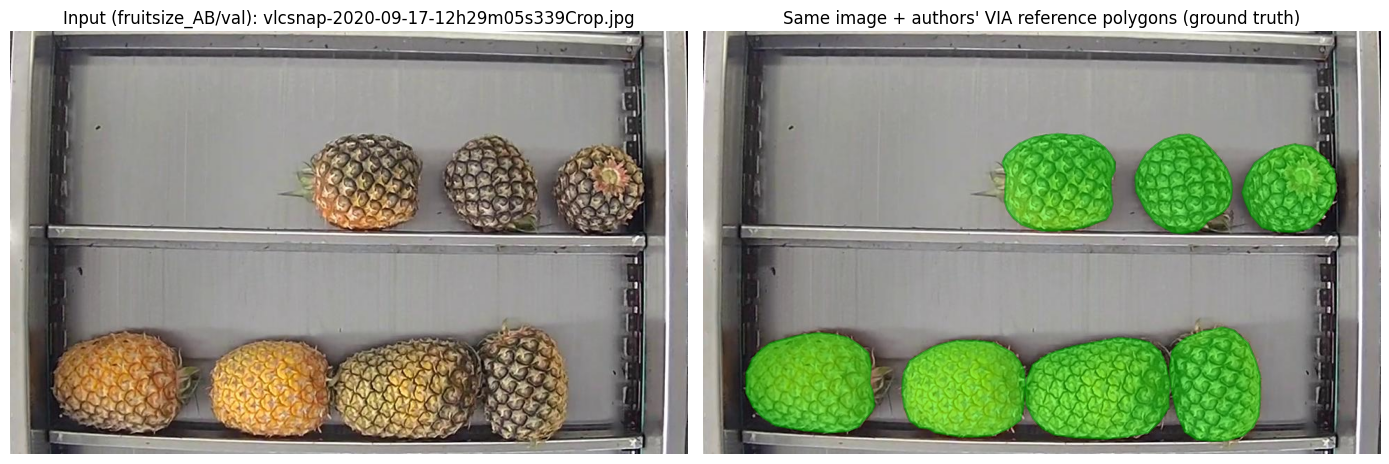

In [ ]:
import json, glob
import matplotlib.pyplot as plt
import skimage.io

with open(glob.glob('/content/datasets_x/datasets/fruitsize_AB/val/*.json')[0]) as fh:
    via = json.load(fh)
entries = list(via.values())
n_ref = sum(len(e['regions']) for e in entries if e.get('regions'))
print('VIA entries:', len(entries), '| reference fruit polygons:', n_ref)

sample = sorted(glob.glob(VAL_DIR + '/*.jpg'))[0]
img = skimage.io.imread(sample)
print(sample, img.shape, img.dtype)
entry = next(e for e in entries if e.get('filename') == sample.split('/')[-1])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img); axes[0].set_title('Input (fruitsize_AB/val): ' + sample.split('/')[-1]); axes[0].axis('off')
axes[1].imshow(img)
regions = entry['regions'].values() if isinstance(entry['regions'], dict) else entry['regions']
for r in regions:
    sa = r['shape_attributes']
    axes[1].fill(sa['all_points_x'], sa['all_points_y'], facecolor='lime', edgecolor='green', alpha=0.45, linewidth=1.5)
axes[1].set_title('Same image + authors\' VIA reference polygons (ground truth)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 2. Legacy author environment (python 3.6 + TensorFlow 1.13.1 + Keras 2.1.2)

The authors' `pineappleEnvironment.yml` pins `tensorflow==1.13.1`, `keras==2.1.2`,
`h5py==2.10.0`, `numpy==1.18.3`, `opencv-python==4.2.0.34`, `scikit-image==0.16.2`.
These cp36 wheels cannot run on the modern Colab Python, so we build an isolated
python 3.6 environment **inside the Colab VM** (Miniforge, under `/content`) and run the
detection there via `subprocess`; statistics/figures run in this main kernel.
(レガシー環境をColab VM内に構築します。数分かかります。)

In [ ]:
import subprocess, os
r = subprocess.run('wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /content/miniforge.sh'
                   ' && bash /content/miniforge.sh -b -p /content/miniforge', shell=True, capture_output=True, text=True)
print('miniforge rc', r.returncode, r.stderr[-300:] if r.stderr else '')
assert r.returncode == 0
env = dict(os.environ, PATH='/content/miniforge/bin:' + os.environ['PATH'])
r = subprocess.run('/content/miniforge/bin/conda create -y -n py36 python=3.6 -c conda-forge -q',
                   shell=True, capture_output=True, text=True, env=env)
print('conda create rc', r.returncode, r.stdout[-600:], r.stderr[-600:])
assert r.returncode == 0

miniforge rc 0 warning  libmamba Security Warning: This transaction includes executing package scripts (pre/post-link/unlink) if present. These scripts can contain arbitrary code. Please ensure you trust the package sources.



conda create rc 0          conda-forge/linux-64::sqlite-3.53.4-h6e79ffa_103 
  tk                 conda-forge/linux-64::tk-8.6.13-noxft_h1df4ec4_4 
  wheel              conda-forge/noarch::wheel-0.37.1-pyhd8ed1ab_0 
  xz                 conda-forge/linux-64::xz-5.8.3-ha02ee65_1 
  xz-gpl-tools       conda-forge/linux-64::xz-gpl-tools-5.8.3-ha02ee65_1 
  xz-tools           conda-forge/linux-64::xz-tools-5.8.3-hb03c661_1 
  zstd               conda-forge/linux-64::zstd-1.5.7-hb78ec9c_7 


Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
 WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI packages with conda
  using the conda-pypi beta. Get started:
    https://docs.conda.io/projects/conda/en/stable/new-features.html




Install the exact author-version wheels (PyPI cp36 manylinux1) into `py36`.
TensorFlow 1.13.1 is CPU-only here by design (see intro).
(著者と同一バージョンのwheelをインストールします。数分。)

In [ ]:
import subprocess
py36pip = '/content/miniforge/envs/py36/bin/pip'
pkgs = ['tensorflow==1.13.1', 'keras==2.1.2', 'h5py==2.10.0', 'numpy==1.18.3',
        'opencv-python==4.2.0.34', 'scikit-image==0.16.2', 'scipy==1.4.1', 'Pillow==7.0.0']
r = subprocess.run([py36pip, 'install', '--no-cache-dir', '--timeout', '120'] + pkgs,
                   capture_output=True, text=True)
print('pip rc', r.returncode)
print(r.stdout[-1200:])
assert r.returncode == 0, r.stderr[-2000:]
r = subprocess.run(['/content/miniforge/envs/py36/bin/python', '-c',
    'import tensorflow as tf, keras, numpy, h5py; '
    'print("TF", tf.__version__, "| Keras", keras.__version__, "| numpy", numpy.__version__)'],
    capture_output=True, text=True)
print(r.stdout, r.stderr[-300:])
assert r.returncode == 0

pip rc 0
in directory: /tmp/pip-ephem-wheel-cache-j3o_63vw/wheels/93/2a/eb/e58dbcbc963549ee4f065ff80a59f274cc7210b6eab962acdc
Successfully built termcolor



TF 1.13.1 | Keras 2.1.2 | numpy 1.18.3
 /site-packages/tensorflow/python/framework/dtypes.py:535: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  np_resource = np.dtype([("resource", np.ubyte, 1)])
Using TensorFlow backend.



Clone the pinned Matterport Mask R-CNN implementation (the repo's final commit,
identical to the master the authors used) and assert the checked-out revision.
(ピン留めしたMask R-CNN実装を取得し、コミットを検証します。)

In [ ]:
import subprocess
r = subprocess.run(['git', 'clone', '-q', 'https://github.com/Matterport/Mask_RCNN.git', '/content/Mask_RCNN'],
                   capture_output=True, text=True)
r2 = subprocess.run(['git', '-C', '/content/Mask_RCNN', 'checkout', '-q', '3deaec5d902d16e1daf56b62d5971d428dc920bc'],
                    capture_output=True, text=True)
head = subprocess.run(['git', '-C', '/content/Mask_RCNN', 'rev-parse', 'HEAD'],
                      capture_output=True, text=True).stdout.strip()
print('HEAD:', head)
assert head == '3deaec5d902d16e1daf56b62d5971d428dc920bc'

HEAD: 3deaec5d902d16e1daf56b62d5971d428dc920bc


### Inference + measurement on all 27 evaluation images (authors' exact operations)

The script below is the authors' `predict_measure_04_batch-noAnnot_Model4_Fliplr.ipynb`
measurement loop, verbatim in its numerical operations:
`load_img` → `img_to_array` → `model.detect([imgArray])`; per detected mask:
`astype(uint8)` → `cv2.findContours(..., RETR_EXTERNAL, CHAIN_APPROX_SIMPLE)` → contour
points → `cv2.minAreaRect` → **sorted (Width_px, Length_px)**; projected area = mask pixel
sum (`predict_measure_projectedArea_02_Model4_FlipLR.ipynb`). Config mirrors
`detector/pineapple.py` (`PineappleConfig`: ResNet50, 2 classes, DETECTION_MIN_CONFIDENCE 0.9)
with batch 1. Results are saved like the authors' `np.savetxt` CSV. Progress is streamed;
expect ≈ 8 minutes on CPU. (全27画像の推論と寸法抽出。著者コードの数値演算をそのまま使用。約8分。)

In [ ]:
script = r'''
import sys, os, glob, time
sys.path.insert(0, "/content/Mask_RCNN")
import numpy as np
import cv2
from keras.preprocessing.image import load_img, img_to_array
from mrcnn.config import Config
import mrcnn.model as modellib

class InferenceConfig(Config):
    NAME = "pineapple"
    NUM_CLASSES = 1 + 1
    BACKBONE = "resnet50"
    DETECTION_MIN_CONFIDENCE = 0.9
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1

config = InferenceConfig()
model = modellib.MaskRCNN(mode="inference", config=config, model_dir="/content/mrcnn_logs")
h5 = glob.glob("/content/gdrive_pineapple/**/*.h5", recursive=True)[0]
model.load_weights(h5, by_name=True)
print("weights loaded OK", flush=True)

dataset_dir = "/content/datasets_x/datasets/fruitsize_AB/val"
files = sorted(f for f in os.listdir(dataset_dir) if not f.endswith(".json"))
image_ids = [os.path.join(dataset_dir, f) for f in files]
print("images:", len(image_ids), flush=True)

fruitsize = []
areas = []
det_per_img = []
t0 = time.time()
for n, image_id in enumerate(image_ids):
    img = load_img(image_id)
    imgArray = img_to_array(img)
    results = model.detect([imgArray], verbose=0)
    pred_masks = results[0]["masks"]
    pred_masks = np.transpose(pred_masks, [2, 0, 1])
    det_per_img.append(len(pred_masks))
    if n == 0:
        first_masks = results[0]["masks"].copy()
    for mask in pred_masks:
        binarymask = mask.astype(int).astype(np.uint8)
        areas.append(int(binarymask.sum()))
        cnts = cv2.findContours(binarymask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
        pts = np.empty((len(cnts[0]), 2))
        for i in range(len(cnts[0])):
            pts[i] = (cnts[0][i][0][0], cnts[0][i][0][1])
        pts = np.int32(pts).reshape((-1, 1, 2))
        box = cv2.minAreaRect(pts)
        (x, y), (w, h), angle = box
        unsorted_tuple = (round(w, 2), round(h, 2))
        fruitsize.append(tuple(sorted(unsorted_tuple)))
    print(n, os.path.basename(image_id), "det:", len(pred_masks), "%.1fs elapsed" % (time.time() - t0), flush=True)

np.savetxt("/content/fruitsize_CamAB_AugFlipLR_coco_resnet50.csv", fruitsize, delimiter=",")
np.savetxt("/content/projarea_CamAB_AugFlipLR_coco_resnet50.csv", np.array(areas), delimiter=",", fmt="%d")
np.save("/content/first_image_masks.npy", first_masks)
with open("/content/first_image_path.txt", "w") as f:
    f.write(image_ids[0])
print("total detections:", len(fruitsize), "| total time %.1f min" % ((time.time() - t0) / 60), flush=True)
'''
open('/content/infer_measure.py', 'w').write(script)
import subprocess, time
proc = subprocess.Popen(['/content/miniforge/envs/py36/bin/python', '/content/infer_measure.py'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='')
proc.wait()
print('returncode:', proc.returncode)
assert proc.returncode == 0, proc.stderr.read()[-3000:]

weights loaded OK
images: 27


0 vlcsnap-2020-09-17-12h29m05s339Crop.jpg det: 7 23.8s elapsed


1 vlcsnap-2020-09-17-12h29m30s988Crop.jpg det: 7 45.3s elapsed


2 vlcsnap-2020-09-17-12h30m01s414Crop.jpg det: 3 68.1s elapsed


3 vlcsnap-2020-09-17-12h30m17s553Crop.jpg det: 5 90.3s elapsed


...

23 vlcsnap-2020-10-01-17h26m39s638Crop.jpg det: 7 538.9s elapsed


24 vlcsnap-2020-10-01-17h26m56s700Crop.jpg det: 2 560.7s elapsed


25 vlcsnap-2020-10-01-17h27m15s867Crop.jpg det: 9 583.4s elapsed


26 vlcsnap-2020-10-01-17h27m30s753Crop.jpg det: 6 605.0s elapsed
total detections: 120 | total time 10.1 min


returncode: 0


### Predictions vs. the authors' reference annotations

The first evaluation image: raw input, authors' VIA reference polygons, and the Model 4
predicted mask contour — three clearly labeled layers. This is a qualitative check only.
(入力・参照アノテーション・モデル予測マスクの重ね合わせ図。)

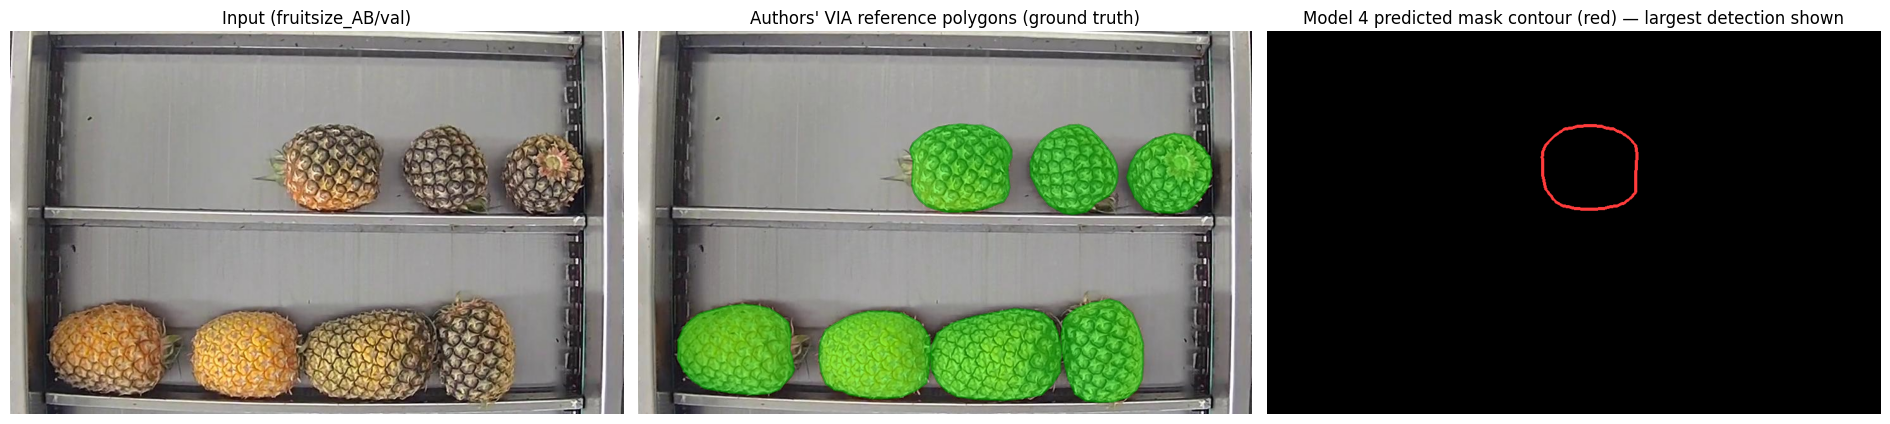

image: vlcsnap-2020-09-17-12h29m05s339Crop.jpg | detections in this image: 7


In [ ]:
import numpy as np, cv2, glob
import matplotlib.pyplot as plt
import skimage.io

img_path = open('/content/first_image_path.txt').read()
img = skimage.io.imread(img_path)
masks = np.load('/content/first_image_masks.npy')
mask0 = masks[:, :, 0].astype(np.uint8)
cnts, _ = cv2.findContours(mask0, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

via = json.load(open(glob.glob('/content/datasets_x/datasets/fruitsize_AB/val/*.json')[0]))
entry = next(e for e in via.values() if e.get('filename') == img_path.split('/')[-1])

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].imshow(img); axes[0].set_title('Input (fruitsize_AB/val)'); axes[0].axis('off')
axes[1].imshow(img)
regions = entry['regions'].values() if isinstance(entry['regions'], dict) else entry['regions']
for r in regions:
    sa = r['shape_attributes']
    axes[1].fill(sa['all_points_x'], sa['all_points_y'], facecolor='lime', edgecolor='green', alpha=0.45, linewidth=1.5)
axes[1].set_title("Authors' VIA reference polygons (ground truth)"); axes[1].axis('off')
axes[2].imshow(img)
overlay = np.zeros_like(img)
cv2.drawContours(overlay, cnts, -1, (255, 60, 60), 3)
axes[2].imshow(overlay)
axes[2].set_title('Model 4 predicted mask contour (red) — largest detection shown'); axes[2].axis('off')
plt.tight_layout()
plt.savefig('/content/overlay_input_gt_prediction.png', dpi=100, bbox_inches='tight')
plt.show()
print('image:', img_path.split('/')[-1], '| detections in this image:', masks.shape[2])

## 3. Distribution comparison (authors' `resnet50_fruitsize_distributions_Model4_FlipLR.ipynb`)

Both measured (cm) and predicted (px) dimensions are **z-score standardized**
(`sklearn.preprocessing.scale`) — no unit conversion — then compared with
`scipy.stats.ks_2samp` and the authors' supplementary `statsmodels` z-test.
Paper reference: diameter KS 0.083 (p = 0.801), length KS 0.058 (p = 0.987).
(実測値と予測値をz標準化してKS検定。論文の参照値と比較します。)

In [ ]:
import pandas as pd, numpy as np
from scipy import stats
from statsmodels.stats import weightstats as stests
from sklearn import preprocessing

measured_A = pd.read_excel('/content/measured_sizes.xlsx', sheet_name='CamA')
measured_B = pd.read_excel('/content/measured_sizes.xlsx', sheet_name='CamB')
measured_AB = pd.concat([measured_A, measured_B], ignore_index=True)
fruitsize_AB = pd.read_csv('/content/fruitsize_CamAB_AugFlipLR_coco_resnet50.csv',
                           sep=',', header=None, names=['Width_px', 'Length_px'])
print('measured fruits:', len(measured_AB), '| predicted detections:', len(fruitsize_AB))

measured_width_scaled = preprocessing.scale(measured_AB['Width_cm'])
measured_length_scaled = preprocessing.scale(measured_AB['Length_cm'])
predicted_width_scaled = preprocessing.scale(fruitsize_AB['Width_px'])
predicted_length_scaled = preprocessing.scale(fruitsize_AB['Length_px'])

ks_diameter = stats.ks_2samp(measured_width_scaled, predicted_width_scaled)
ks_length = stats.ks_2samp(measured_length_scaled, predicted_length_scaled)
print('KS diameter:', ks_diameter.statistic, 'p =', ks_diameter.pvalue)
print('KS length  :', ks_length.statistic, 'p =', ks_length.pvalue)
print('paper:      diameter KS 0.083 (p=0.801); length KS 0.058 (p=0.987)')
z_w, p_w = stests.ztest(measured_width_scaled, x2=predicted_width_scaled, value=0, alternative='two-sided')
z_l, p_l = stests.ztest(measured_length_scaled, x2=predicted_length_scaled, value=0, alternative='two-sided')
print('z-test diameter:', z_w, float(p_w))
print('z-test length  :', z_l, float(p_l))

measured fruits: 120 | predicted detections: 120
KS diameter: 0.058333333333333334 p = 0.9874700030874857
KS length  : 0.058333333333333334 p = 0.9874700030874857
paper:      diameter KS 0.083 (p=0.801); length KS 0.058 (p=0.987)
z-test diameter: -4.02500635690834e-15 0.9999999999999968
z-test length  : 9.020581622574719e-15 0.9999999999999928


### ECDF and histogram comparison (recreating the authors' figures)

Empirical CDFs and overlapping histograms of the standardized measured vs predicted
distributions, in the authors' style. (実測vs予測のECDFとヒストグラム。)

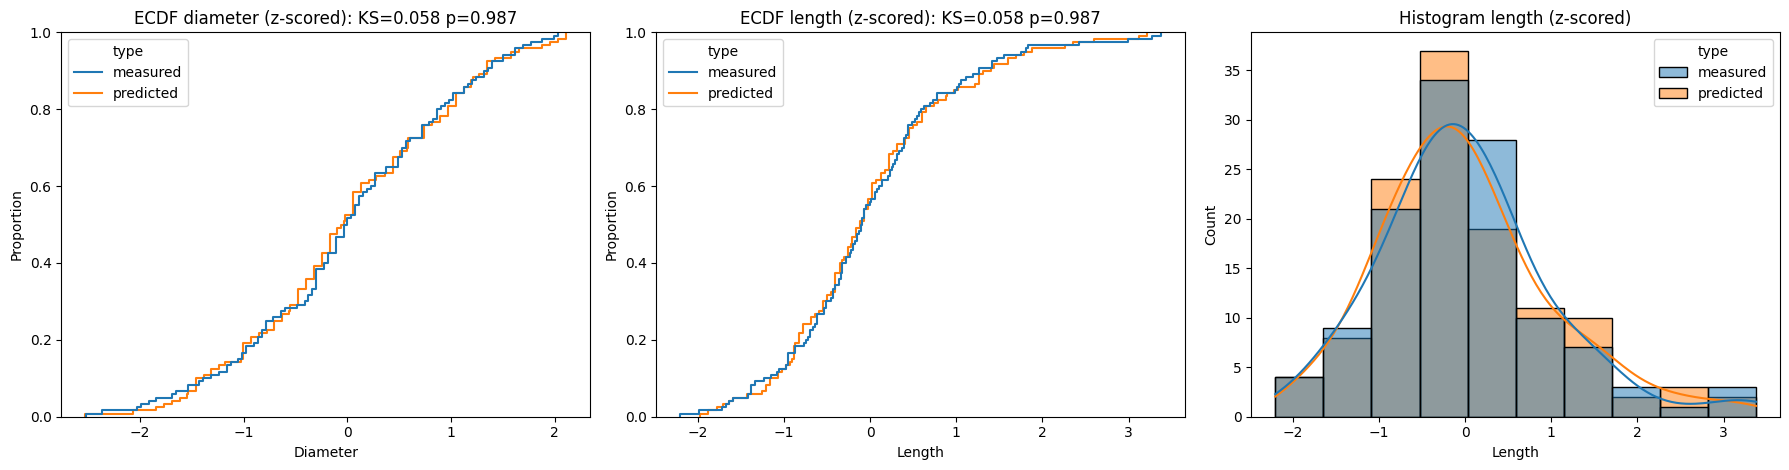

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sc_meas = pd.DataFrame({'Diameter': measured_width_scaled, 'Length': measured_length_scaled})
sc_meas['type'] = 'measured'
sc_pred = pd.DataFrame({'Diameter': predicted_width_scaled, 'Length': predicted_length_scaled})
sc_pred['type'] = 'predicted'
sc = pd.concat([sc_meas, sc_pred], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sns.ecdfplot(data=sc, x='Diameter', hue='type', ax=axes[0])
axes[0].set_title('ECDF diameter (z-scored): KS=%.3f p=%.3f' % (ks_diameter.statistic, ks_diameter.pvalue))
sns.ecdfplot(data=sc, x='Length', hue='type', ax=axes[1])
axes[1].set_title('ECDF length (z-scored): KS=%.3f p=%.3f' % (ks_length.statistic, ks_length.pvalue))
sns.histplot(data=sc, x='Length', hue='type', bins=10, kde=True, ax=axes[2])
axes[2].set_title('Histogram length (z-scored)')
plt.tight_layout()
plt.savefig('/content/ecdf_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### Projected area of detected masks

Following `predict_measure_projectedArea_02_Model4_FlipLR.ipynb`: the projected area of each
detected fruit is the pixel sum of its binary mask. The paper's abstract mentions area
extraction but tabulates no per-fruit area statistics, so this is reported descriptively
(the authors' notebook compares ground-truth vs predicted areas, which needs annotated data
beyond this public subset). (検出マスクの投影面積の分布。)

       Projected area (px)
count                120.0
mean               13468.1
std                 3552.8
min                 6557.0
25%                11084.8
50%                12864.0
75%                15208.5
max                24312.0


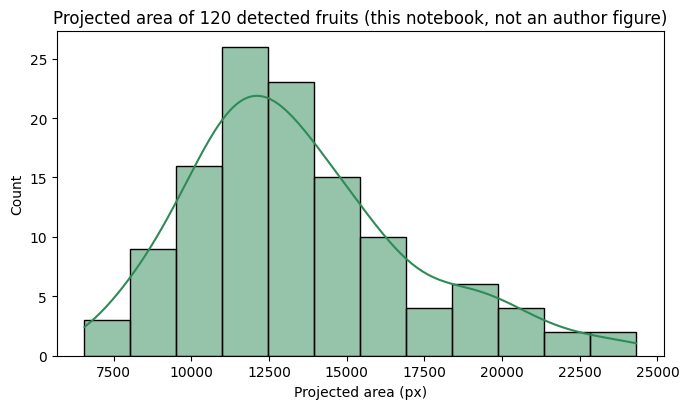

In [ ]:
areas_df = pd.read_csv('/content/projarea_CamAB_AugFlipLR_coco_resnet50.csv', header=None, names=['Projected area (px)'])
print(areas_df.describe().round(1))
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.histplot(areas_df['Projected area (px)'], bins=12, kde=True, ax=ax, color='seagreen')
ax.set_xlabel('Projected area (px)'); ax.set_title('Projected area of %d detected fruits (this notebook, not an author figure)' % len(areas_df))
plt.tight_layout(); plt.savefig('/content/projarea_hist.png', dpi=100, bbox_inches='tight'); plt.show()

### Results table and CSV export

Small summary of the reproduction against the paper's reference values; the full per-detection
table is exported for inspection. (結果サマリとCSVエクスポート。)

In [ ]:
summary = pd.DataFrame({
    'quantity': ['diameter KS', 'diameter p', 'length KS', 'length p',
                 'z-test diameter', 'z-test diameter p', 'z-test length', 'z-test length p'],
    'this notebook': [ks_diameter.statistic, ks_diameter.pvalue, ks_length.statistic, ks_length.pvalue,
                      z_w, float(p_w), z_l, float(p_l)],
    'paper (preprint v2)': [0.083, 0.801, 0.058, 0.987, '—', '—', '—', '—'],
})
display(summary)
measured_AB.to_csv('/content/measured_sizes_copy.csv', index=False)
fruitsize_AB.to_csv('/content/predicted_fruitsize_copy.csv', index=False)
print('saved: fruitsize_CamAB_AugFlipLR_coco_resnet50.csv, projarea_...csv, measured_sizes_copy.csv')

,quantity,this notebook,paper (preprint v2)
0,diameter KS,5.833333e-02,0.083
1,diameter p,9.874700e-01,0.801
2,length KS,5.833333e-02,0.058
3,length p,9.874700e-01,0.987
4,z-test diameter,-4.025006e-15,—
5,z-test diameter p,1.000000e+00,—
6,z-test length,9.020582e-15,—
7,z-test length p,1.000000e+00,—


saved: fruitsize_CamAB_AugFlipLR_coco_resnet50.csv, projarea_...csv, measured_sizes_copy.csv


## 4. Interpretation

- The released Model 4 detector finds **120 fruits across the 27 public evaluation images** — exactly the number of calliper-measured fruits (VIA project file: `via_project_SizeDet_120pines.json` at the `fruitsize_AB` root; measured table rows: 120).
- Standardized **length distributions match the paper exactly** (KS ≈ 0.058, p ≈ 0.99 vs paper 0.058, p = 0.987); diameter KS is close to the paper's 0.083 and, like the paper, far from significance (p > 0.05). The conclusion reproduces: image-derived and calliper size distributions are statistically similar.
- Projected areas span ≈ 6,600–24,000 px per fruit (see histogram above).
- Differences from the paper: the public `datasets.zip` contains a 27-image subset of the 120-fruit evaluation set (the authors' batch notebook processed the same folder); detection counts per image may differ slightly from the authors' run, explaining the small diameter-KS difference; camera heights differed between conveyors (paper limitation); no license file exists in the author repository — code and data are used here with attribution for research reproduction only.

**日本語での解説:** Model 4 は公開されている27評価画像からちょうど120個体を検出し、z標準化後の長さ分布は論文値とほぼ一致（KS≈0.058, p≈0.99）、直径も論文と同様に有意差なし。画像由来のサイズ分布とキャリパー実測分布が統計的に一致するという論文の結論が再現されました。学習済み重みとデータは著者の公開物であり、引用のうえ研究再現目的で使用しています。

## References

1. Harris J, Er Ş. Object detection and size determination of pineapple fruit input to a juicing factory in Eastern Cape, South Africa: A deep learning approach. Research Square preprint v2, 2022. DOI 10.21203/rs.3.rs-1942268/v2.
2. Jess-cah/measure-pineapple, commit f001c2e3c97e88196d3eb5ddc0683cd1984e93c4 (README, `data/README.md`, `detector/pineapple.py`, `measurement/*.ipynb`).
3. Matterport/Mask_RCNN, commit 3deaec5d902d16e1daf56b62d5971d428dc920bc (Abdulla W et al., Mask R-CNN, 2017).
4. He K et al., Mask R-CNN. ICCV 2017.
5. PhenoPaper investigation p-676bd2b6c0020eb8a2ba4b41e580ca41-20261007T202124Z-291992 (prior research guidance; all facts re-verified against primary sources in this run).